In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [21]:
fashion_mnist=tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test)=fashion_mnist.load_data()

In [22]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

In [23]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [24]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [25]:
model = models.Sequential([
layers.Input(shape=(28, 28, 1)),


layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
layers.MaxPooling2D((2, 2)),


layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
layers.MaxPooling2D((2, 2)),


layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
layers.MaxPooling2D((2, 2)),


layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dropout(0.5),
layers.Dense(10, activation="softmax")
])

In [26]:
model.compile(
optimizer="adam",
loss="categorical_crossentropy",
metrics=["accuracy"]
)

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stopping = EarlyStopping(
monitor="val_loss",
patience=3,
restore_best_weights=True
)

In [29]:
checkpoint = ModelCheckpoint(
"fashion_mnist_cnn.h5",
monitor="val_accuracy",
save_best_only=True
)

In [30]:
history = model.fit(
x_train, y_train,
epochs=20,
batch_size=128,
validation_split=0.1,
callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6513 - loss: 0.9640

422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7615 - loss: 0.6621 - val_accuracy: 0.8595 - val_loss: 0.3759
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8535 - loss: 0.4106

422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.8584 - loss: 0.3946 - val_accuracy: 0.8732 - val_loss: 0.3236
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8782 - loss: 0.3388

422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.8801 - loss: 0.3353 - val_accuracy: 0.8857 - val_loss: 0.3016
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8892 - loss: 0.3069

422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.8906 - loss: 0.3018 - val_accuracy: 0.9005 - val_loss: 0.2654
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8990 - loss: 0.2789

...

422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.9289 - loss: 0.1966 - val_accuracy: 0.9197 - val_loss: 0.2245
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.9350 - loss: 0.1800 - val_accuracy: 0.9152 - val_loss: 0.2230
Epoch 12/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9372 - loss: 0.1680

422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.9371 - loss: 0.1714 - val_accuracy: 0.9205 - val_loss: 0.2237
Epoch 13/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9443 - loss: 0.1524

422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9409 - loss: 0.1598 - val_accuracy: 0.9240 - val_loss: 0.2221
Epoch 14/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9438 - loss: 0.1516

422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.9435 - loss: 0.1534 - val_accuracy: 0.9247 - val_loss: 0.2236
Epoch 15/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.9481 - loss: 0.1384 - val_accuracy: 0.9223 - val_loss: 0.2331
Epoch 16/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9523 - loss: 0.1304

422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9512 - loss: 0.1322 - val_accuracy: 0.9253 - val_loss: 0.2209
Epoch 17/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.9547 - loss: 0.1221 - val_accuracy: 0.9245 - val_loss: 0.2293
Epoch 18/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.9572 - loss: 0.1145 - val_accuracy: 0.9203 - val_loss: 0.2832
Epoch 19/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9600 - loss: 0.1064 - val_accuracy: 0.9248 - val_loss: 0.2441


In [31]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9208


In [32]:
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

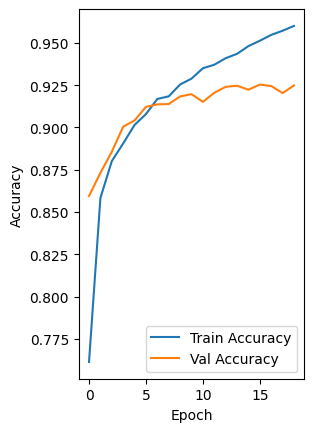

In [33]:
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

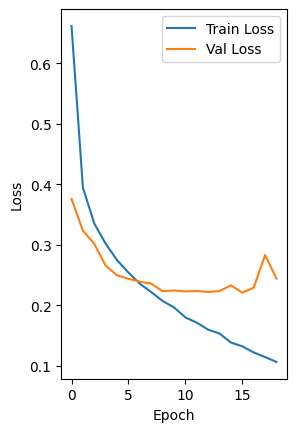

In [34]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [35]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [37]:
model.save("fashion_mnist_cnn_final.keras")

In [38]:
print("Model training complete and saved.")

Model training complete and saved.


C:\Users\devs4\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded successfully.
Test Accuracy: 0.9208
Test Loss: 0.2392
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


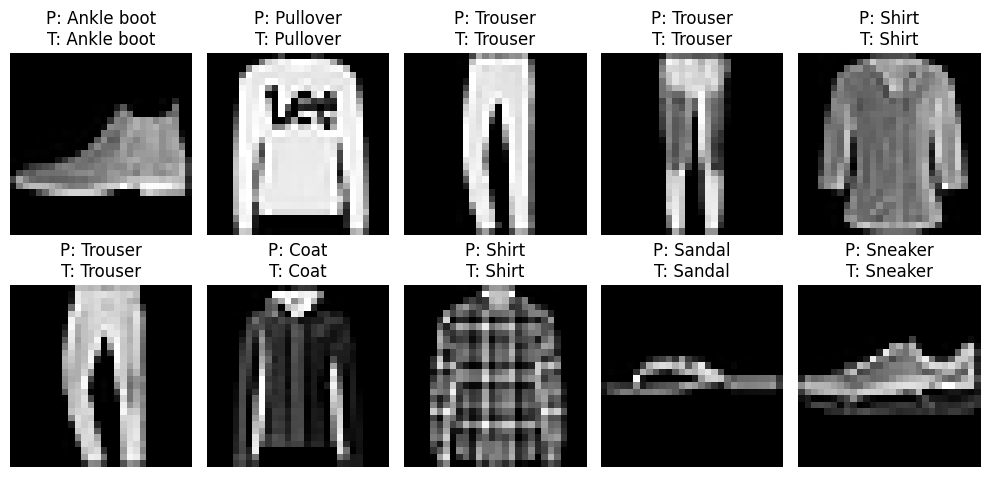

In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# 1. Load trained model
model = tf.keras.models.load_model("fashion_mnist_cnn_final.keras")
print("Model loaded successfully.")

# 2. Load test data
(_, _), (x_test, y_test) = fashion_mnist.load_data()

# 3. Preprocess test data
x_test = x_test.astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1)

y_test_cat = to_categorical(y_test, 10)

# 4. Evaluate model
loss, accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# 5. Class labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 6. Predict on sample images
predictions = model.predict(x_test)

# 7. Visualize predictions
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i]]
    plt.title(f"P: {predicted_label}\nT: {true_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()
